# 1. 환경 설정

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import math
import numpy as np

In [ ]:
def setup_data():
    org_path = "../"
    raw_path = f"{org_path}data/raw/"
    prc_path = f"{org_path}data/processed/"
    eda_path = f"{org_path}outputs/eda/"
    seed = 42

    print("변수 세팅 완료")
    return org_path, raw_path, prc_path, eda_path, seed

# 사용 예시 (반환값 9개)
org_path, raw_path, prc_path, eda_path, seed = setup_data()

# 2. 테이블 로드

In [ ]:
def load_multiple_csv(base_path: str, filenames: list[str]) -> dict[str, pd.DataFrame]:
    """
    여러 CSV 파일을 한 번에 불러와 DataFrame 딕셔너리로 반환합니다.
    
    Parameters
    ----------
    base_path : str
        기본 경로 (예: "data/raw/")
    filenames : list[str]
        확장자를 제외한 파일명 리스트 (예: ["orders", "products", "users"])

    Returns
    -------
    dict[str, pd.DataFrame]
        각 파일명을 key, DataFrame을 value로 하는 딕셔너리
    """
    base = Path(base_path)
    dataframes = {}

    for name in filenames:
        file_path = base / f"{name}.csv"
        if not file_path.exists():
            print(f"파일 없음: {file_path}")
            continue
        df = pd.read_csv(file_path)
        dataframes[name] = df
        print(f"{name}.csv 로드 완료. shape={df.shape}")

    return dataframes

In [ ]:
file_list = [
    "distribution_centers", "events", "inventory_items",
    "order_items", "orders", "products", "users"
]

# CSV 로드
dfs = load_multiple_csv(raw_path, file_list)

In [ ]:
# 변수 자동 생성
for name, df in dfs.items():
    globals()[name] = df
    print(f"변수 생성 완료: {name} (shape={df.shape})")

# 3. 테이블별 요약 정보 확인

## 3.1 distribution_centers

In [ ]:
# 1단계: 자동 추론
distribution_centers =  distribution_centers.convert_dtypes()

# 2단계: 중요한 컬럼만 명시적으로
force_dtypes = {
    'id': 'string'
}
distribution_centers = distribution_centers.astype({k: v for k, v in force_dtypes.items() if k in distribution_centers.columns})

In [ ]:
distribution_centers.info()

In [ ]:
distribution_centers.describe(include='all')

In [ ]:
distribution_centers

## 3.1 events

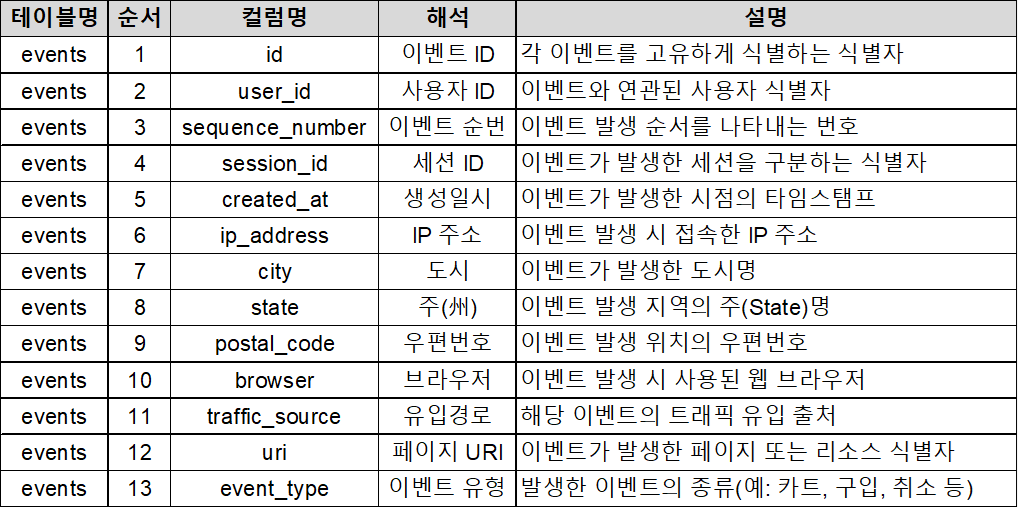

In [ ]:
# 데이터 타입 변환
# 1단계: 자동 추론
events =  events.convert_dtypes()

# 2단계: 중요한 컬럼만 명시적으로
# 2단계: 중요한 컬럼만 명시적으로
force_dtypes = {
    'id': 'string',
    'user_id': 'string',
    'sequence_number': 'string',
}

events = events.astype({k: v for k, v in force_dtypes.items() if k in events.columns})

In [ ]:
# 1) 컬럼 변수 정의
cat_cols = events.select_dtypes(include=['string', 'category']).columns.tolist()
key_cols = ['id', 'user_id', 'session_id', 'ip_address']
date_cols = ['created_at']
derived_time_cols = ['year', 'month', 'day', 'hour', 'minute', 'second']

# 2) key 컬럼 제외
cat_cols = [col for col in cat_cols if col not in key_cols + date_cols]

# 3) 출력 확인
print("범주형 컬럼:", cat_cols)
print("키 컬럼:", key_cols)
print("시간 컬럼:", date_cols, derived_time_cols)

파생 변수 생성

In [ ]:
# datetime으로 변환
events['created_at'] = pd.to_datetime(events['created_at'], errors='coerce')

# 파생 변수 생성
events['year'] = events['created_at'].dt.year.astype('Int64')
events['month'] = events['created_at'].dt.month.astype('Int64')
events['day'] = events['created_at'].dt.day.astype('Int64')
events['hour'] = events['created_at'].dt.hour.astype('Int64')
events['minute'] = events['created_at'].dt.minute.astype('Int64')
events['second'] = events['created_at'].dt.second.astype('Int64')

# 타입 변환
for c in derived_time_cols:
    events[c] = events[c].astype('Int64').astype('string')

# 사용자 ID 존재 여부 파생 변수 생성
events['is_user_id_present'] = events['user_id'].notna()


# cat_cols에 파생 시간 변수 포함
cat_cols.extend(derived_time_cols+['is_user_id_present'])

In [ ]:
# uri 분석을 위한 파생 변수 생성
def extract_first_two_segments(uri):
    segs = uri.split('/')
    return f"/{segs[1]}" if len(segs) >= 2 else uri

events['uri_splt'] = events['uri'].apply(extract_first_two_segments)

# cat_cols에 파생 변수 포함
cat_cols.append('uri_splt')

In [ ]:
# 유저별 생성 세션 수 파생 변수 생성
events['unique_session_count'] = (
    events.groupby('user_id')['session_id']
    .transform('nunique')
)

# 한 세션 별 활동 수 파생 변수 생성
events['activity_count'] = events.groupby(['session_id']).transform('size')

### 데이터 전체 구조

In [ ]:
events.describe(include='all')

In [ ]:
events.info(show_counts=True)

In [ ]:
events.head()

### 주요 변수 분포 및 특성 분석

**범주형 변수 분포**

In [ ]:
def plot_categorical_overview(
    df,
    cols,
    per_row=3,
    rotate=45,
    per_ax_size=(5, 3.5),
    na_label="NA",
    top_k=60,          # 기본 top_k
    topk_map=None,     # 특정 컬럼만 다른 top_k
    exclude_cols=None  # ⭐ 특정 컬럼 제외
):
    # ------------------------------
    # 0) 제외 컬럼 처리
    # ------------------------------
    exclude_cols = exclude_cols or []
    cols = [c for c in cols if c not in exclude_cols]

    n = len(cols)
    if n == 0:
        print("No categorical columns to plot after excluding.")
        return

    # ------------------------------
    # 1) subplot 설정
    # ------------------------------
    nrows = math.ceil(n / per_row)
    figsize = (per_ax_size[0] * per_row, per_ax_size[1] * nrows)
    fig, axes = plt.subplots(nrows, per_row, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    topk_map = topk_map or {}

    # ------------------------------
    # 2) 컬럼별 시각화
    # ------------------------------
    for i, col in enumerate(cols):
        ax = axes[i]

        # 결측 치환
        s = df[col].fillna(na_label)

        # 빈도 집계
        vc = s.value_counts(dropna=False)
        if vc.empty:
            ax.set_title(f"{col}\n(모든 값 결측)")
            ax.axis("off")
            continue

        # 값 기준 정렬
        vc = vc.sort_index()

        # 개별 top_k 적용 여부
        k = topk_map.get(col, top_k)
        if k is not None:
            vc = vc.head(k)

        counts = vc.values
        labels = vc.index.astype(str)
        x = np.arange(len(vc))

        # 막대그래프
        ax.bar(x, counts)

        # 평균선
        mean_cnt = counts.mean()
        ax.axhline(mean_cnt, linestyle="--", linewidth=1,
                   label=f"mean={mean_cnt:.0f}")

        # x축 설정
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=rotate)

        # 통계 정보
        uniq = df[col].nunique(dropna=False)
        uniq_fmt = f"{uniq:,}"

        total = vc.sum()
        top1_share = vc.iloc[0] / total if total > 0 else 0
        top5_share = vc.head(5).sum() / total if total > 0 else 0

        ax.set_title(col, fontsize=10)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8, loc="upper right")

        # 각주
        ax.text(
            1.02, 0.5,
            f"uniq={uniq_fmt}\ntop1={top1_share:.1%}\ntop5={top5_share:.1%}",
            transform=ax.transAxes,
            va="center",
            fontsize=8
        )

    # 남은 subplot 삭제
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

In [ ]:
# 컬럼별 개별 top_k 설정
special_topk = {
    "city": 10,         # city: 상위 10개까지만 표시
    "state": 10,        # state: 상위 10개까지만 표시
    "postal_code": 10,  # postal_code: 상위 10개까지만 표시
}
# 제외 컬럼 설정
exclude_cols = ["uri"]

plot_categorical_overview(
    events,
    cols=cat_cols,
    per_row=2,
    rotate=45,
    per_ax_size=(10, 4.5),
    na_label="NA",
    top_k=60,
    topk_map=special_topk,
    exclude_cols=exclude_cols,
)

In [ ]:
for col in cat_cols:
    print(f"=== {col} ===")
    vals = events[col].value_counts(dropna=False, normalize=True)
    print(vals.head(10).round(3))  # 소수점 2자리까지 반올림

수치형 변수 분포
- 없음

In [1]:
def plot_numeric_combo(df, cols, bins=30, figsize_per_row=(10, 3.5)):
    """
    numeric column 하나당: 
    - 왼쪽: Histogram
    - 오른쪽: Boxplot
    형태로 한 줄(row)에 배치하여 모든 수치형 변수를 시각화한다.
    """

    # 실제로 수치형인 컬럼만 필터링
    numeric_cols = [
        c for c in cols
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
    ]

    if not numeric_cols:
        print("수치형 컬럼이 없습니다.")
        return

    n = len(numeric_cols)

    # 전체 Figure 설정
    fig, axes = plt.subplots(
        nrows=n,
        ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n)
    )

    # axes가 2차원 배열이 아닌 경우 reshape
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(numeric_cols):
        s = df[col].dropna()

        # 1) Histogram
        ax_hist = axes[i, 0]
        ax_hist.hist(s, bins=bins, color="skyblue", edgecolor="black")
        ax_hist.set_title(f"{col} — Histogram")
        ax_hist.set_ylabel("Count")

        # 평균·중앙값 선
        if len(s) > 0:
            ax_hist.axvline(s.mean(), color="red", linestyle="--", linewidth=1,
                            label=f"mean={s.mean():.2f}")
            ax_hist.axvline(s.median(), color="green", linestyle=":", linewidth=1,
                            label=f"median={s.median():.2f}")
            ax_hist.legend(fontsize=8)

        # 2) Boxplot
        ax_box = axes[i, 1]
        ax_box.boxplot(s, vert=False)
        ax_box.set_title(f"{col} — Boxplot")

    plt.tight_layout()
    plt.show()

In [ ]:
plot_numeric_combo(train_df, int_cols+float_cols)

변수별 특징 확인

In [ ]:
# 세션 단위 user_id 중복 여부 집계
counts_dup = (
    events.groupby('session_id')['is_user_id_present']
          .nunique()
          .value_counts()
)
print("세션별 user_id 중복 여부 요약:\n", counts_dup.apply(lambda x: f"{x:,}"), "\n")
# 중복 없음 

# 세션 단위 user_id 존재 여부 집계
counts_no_dup = (
    events.groupby('session_id')['is_user_id_present']
          .first()
          .value_counts()
)
print("세션별 user_id 포함 여부 요약:\n", counts_no_dup.apply(lambda x: f"{x:,}"), "\n")

# user_id의 고유 값 개수 산출
print(f"user_id 고유 개수: {events['user_id'].nunique(dropna=True):,}")

# user_id 기준 세션 생성 수 집계
sessions_per_user = (
    events[['user_id', 'session_id']]
    .drop_duplicates()               # 동일 user_id 내 중복 세션 제거
    .groupby('user_id')['session_id']
    .nunique()                       # user_id별 세션 수 계산
)

print(f"\n전체 user_id 수: {sessions_per_user.shape[0]:,}")
print("user_id 기준 세션 생성 수 요약:")    
print(sessions_per_user.reset_index(name='session_count')['session_count'].describe().apply(lambda x: f"{x:,}"))

# 반 정도는 1회 구입후 재구매 진행 없음. 단, 반이상은 다빈도로 재구매 진행함

In [ ]:
sessions_per_user.reset_index(name='session_count')

In [ ]:
print(f"Shape: {events.shape}")  # 데이터 행, 열 출력
print(f"Unique id count: {events['id'].nunique()}")  # id 컬럼의 고유값 개수
print(f"Min id: {events['id'].min()}, Max id: {events['id'].max()}")  # id 컬럼 최소/최대값

In [ ]:
events.sort_values(by='id', key=lambda x: x.astype(int)).head(10)

In [ ]:
# 'session_id'별로 그룹화 후 집계 수행
# - 'purchase_count': 각 세션에서 event_type이 'purchase'인 횟수 계산
# - 'unique_ip_count': 각 세션에서 유니크한 'ip_address' 개수 계산
# 세션별 실질적인 구매 이벤트 빈도와 접속 IP 다양성을 파악합니다.
# 이는 세션 생성 기준을 이해하고, 사용자 행동 분석 및 이상 탐지에 활용할 수 있습니다.
result = events.groupby('session_id').agg(
    purchase_count = ('event_type', lambda x: (x == 'purchase').sum()),
    unique_ip_count = ('ip_address', 'nunique')
).reset_index()

# 집계 결과 출력
print(result)

In [ ]:
# 한 세션 당 동일 ip임
print(result['unique_ip_count'].value_counts())

# 구입 전환되면 세션이 종료되는 듯함
print(result['purchase_count'].value_counts())

# purchase_count가 1인 애들 대상으로 마지막이 purchase인지 확인 필요

In [ ]:
# purchase_count가 1인 세션에서 마지막 이벤트의 종류 확인
# 결과를 통해 purchase_count가 1인 세션들은 마지막 이벤트가 모두 'purchase'임을 확인

# purchase_count가 1인 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = result[result['purchase_count'] == 1]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print(last_events['event_type'].value_counts())

In [ ]:
# purchase_count가 0인 세션에서 마지막 이벤트의 종류 확인
# 결과를 통해 purchase_count가 0인 세션들은 마지막 이벤트가 모두 'purchase'임을 확인

# purchase_count가 0인 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = result[result['purchase_count'] == 0]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print(last_events['event_type'].value_counts())

In [ ]:
# event_type이 cancel인 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = last_events[last_events['event_type'] == 'cancel']['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

print(f"===== 전체 event_type ===== \n{events['event_type'].value_counts()}")
print(f"===== purchase_count가 0이면서 event_type이 cancel인 경우 ===== \n {len(purchase_sessions)}")
print(f"===== event_type이 cancel인 경우, user_id ===== \n {filtered_events['user_id'].value_counts(dropna=False)}")
print(f"===== 전체 user_id가 null인 경우 ===== \n {events['user_id'].isna().sum()}")

# user_id가 없는 세션에서 구입 전환 이루어 지지 않을 경우 cancel로 마무리
print(filtered_events.sort_values(by='id', key=lambda x: x.astype(int)).head(10))

In [ ]:
# user_id가 있는 세션에서 마무리 유형 확인 -- purchase만 존재
# user_id가 있는 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions = events[events['user_id'].notna()]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print('events user_id 존재: ', events['user_id'].notna().sum())
print(last_events['event_type'].value_counts())

In [ ]:
# user_id가 없는 세션에서 마무리 유형 확인
# user_id가 없는 세션만 필터링하여 해당 세션 목록 생성
purchase_sessions =  events[events['user_id'].isna()]['session_id']

# 필터링된 세션에 속하는 이벤트만 선택
filtered_events = events[events['session_id'].isin(purchase_sessions)]

# 올바른 비교를 위해 'sequence_number'를 정수형으로 변환
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

# 각 세션별로 가장 큰 sequence_number 값을 가지는 행의 인덱스 추출 (즉, 마지막 이벤트)
idx = filtered_events.groupby('session_id')['sequence_number'].idxmax()

# 최대 sequence_number를 가진 이벤트 행 선택하여 session_id와 event_type 확인
last_events = filtered_events.loc[idx, ['session_id', 'event_type']]

# 마지막 이벤트 타입별 빈도 출력
print('events user_id 미존재: ', events['user_id'].isna().sum())
print(last_events['event_type'].value_counts())

In [ ]:
filtered_events = events[events['user_id'].isna()]
filtered_events['sequence_number'] = filtered_events['sequence_number'].astype(int)

filtered_events.sort_values(by=['ip_address', 'session_id', 'sequence_number']).head(40)

In [ ]:
events['event_type'].value_counts()

### 집계

In [ ]:
events.head()

In [ ]:
events.info(show_counts=True)

In [ ]:
df = events[['year','month']].value_counts().reset_index().sort_values(by=['year','month'], key=lambda x: x.astype(int))
print(df)

df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.bar(df['year_month'], df['count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Year-Month")
plt.ylabel("Count")
plt.title("Events by Year-Month")
plt.tight_layout()
plt.show()

# 2019년 12월 : 중국 우한에서 원인불명의 폐렴 보고
# 2020년 1월 30일 : WHO, 국제적 공중보건 비상사태(PHEIC) 선언
# 2020년 3월 11일 ~ 2023년 5월 5일: 코로나 팬데믹 기간

In [ ]:
# hour별 건수 집계
df = (
    events[['hour']]
    .value_counts()                  # hour별 빈도
    .reset_index(name='count')       # count 컬럼 지정
    .sort_values(by='hour', key=lambda x: x.astype(int))          # 시간 오름차순 정렬
)

print(df)

# 막대그래프
plt.figure(figsize=(12, 5))
plt.bar(df['hour'], df['count'])
plt.xticks(df['hour'])               # 0~23 전체 시간이 보이도록
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Events by Hour")
plt.tight_layout()
plt.show()

In [ ]:
# state별 건수 집계
df = (
    events[['state']]
    .value_counts()               # state별 빈도수
    .reset_index(name='count')    # count 컬럼 이름 지정
    .sort_values(by='state')      # state 알파벳 순 정렬
)

print(df)

# 막대그래프 그리기
plt.figure(figsize=(12, 5))
plt.bar(df['state'], df['count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("State")
plt.ylabel("Count")
plt.title("Events by State")
plt.tight_layout()
plt.show()

In [ ]:
# browser별 건수 집계
df = (
    events[['browser', 'traffic_source']]
    .value_counts()                     # browser별 빈도
    .reset_index(name='count')          # count 컬럼 지정
    .sort_values(by='browser')          # browser 알파벳 순 정렬
)
print(df)

# 막대그래프
pivot_df = df.pivot(
    index='browser',
    columns='traffic_source',
    values='count'
).fillna(0)

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.xticks(rotation=45, ha='right')
plt.xlabel("Browser")
plt.ylabel("Count")
plt.title("Events by Browser × Traffic Source")
plt.tight_layout()
plt.show()


In [ ]:
# 유저별 큰 차이 없네
# is_user_id_present × browser × traffic_source 집계
df = (
    events[['is_user_id_present', 'browser', 'traffic_source']]
    .value_counts()
    .reset_index(name='count')
)

# facet용 값 정렬
facet_values = sorted(df['is_user_id_present'].unique())

fig, axes = plt.subplots(
    1, len(facet_values),
    figsize=(6 * len(facet_values), 6),
    sharey=True
)

# 서브플롯이 1개인 경우에도 리스트처럼 다루기 위함
if len(facet_values) == 1:
    axes = [axes]

for ax, val in zip(axes, facet_values):
    sub = df[df['is_user_id_present'] == val].copy()
    sub = sub.sort_values(by='browser')

    pivot_df = (
        sub.pivot(
            index='browser',
            columns='traffic_source',
            values='count'
        )
        .fillna(0)
    )

    pivot_df.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    ax.set_title(f"is_user_id_present = {val}")
    ax.set_xlabel("Browser")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# created_at 컬럼이 datetime이 아니라면 먼저 변환
# events['created_at'] = pd.to_datetime(events['created_at'])

# session_id별 최소/최대 created_at 집계
session_time = (
    events.groupby('session_id')['created_at']
          .agg(start_time='min', end_time='max')
          .reset_index()
)

# 세션 지속시간 계산
session_time['duration'] = session_time['end_time'] - session_time['start_time']
session_time['duration_hour'] = session_time['duration'].dt.total_seconds() / 3600 # 시간 단위 변환
session_time['duration_min'] = session_time['duration'].dt.total_seconds() / 60 # 분 단위 변환
print(session_time.head())

# 원본 events에 merge
events = events.merge(
    session_time,
    on='session_id',
    how='left'
)

plt.figure(figsize=(10, 5))
plt.hist(session_time['duration_hour'], bins=50)
plt.xlabel("Session Duration (Hours)")
plt.ylabel("Count")
plt.title("Distribution of Session Duration (Hours)")
plt.tight_layout()
plt.show()


In [ ]:
# 1) session_time에 is_user_id_present 붙이기
session_time = session_time.merge(
    events[['session_id', 'is_user_id_present']].drop_duplicates(),
    on='session_id',
    how='left'
)

# 2) 고유값 확인 (예: True / False 또는 0 / 1)
categories = sorted(session_time['is_user_id_present'].unique())

# 3) facet histogram
fig, axes = plt.subplots(1, len(categories), figsize=(12, 5), sharey=True)

if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    subset = session_time[session_time['is_user_id_present'] == cat]
    
    ax.hist(subset['duration_hour'], bins=50)
    ax.set_title(f"is_user_id_present = {cat}")
    ax.set_xlabel("Session Duration (Hours)")
    ax.set_ylabel("Count")
    ax.set_xlim(left=0)  # 음수 방지

plt.tight_layout()
plt.show()


### 세부 패턴 및 관계 분석

### 분석 대상 확인

1안: 로그인 유저 대상 재구입 대상 예측

재구입 X인 경우, 34,996건
재구입 O인 경우, 45,048건


(구입 여부)
- train: 최초 구입 이후. 다음 시점(2번째)에 구입을 할 것인가?
- test: 다음 시점(2번째) 이후. 그 다음다음 시점(3번째)에 구입을 할 것인가

(상품 카테고리 예측)
- train: 첫번째 시점에서 구입한 다음. 다음 시점(2번째)에 구입을 할 것인가
- test: 두번째 시점에서 구입한 다음. 다음 시점(3번째)에 구입을 할 것인가

(재구입 시점 예측)
- train: 첫번째 시점에서 구입한 다음. 다음 시점(2번째)에 구입을 할 것인가
- test: 두번째 시점에서 구입한 다음. 다음 시점(3번째)에 구입을 할 것인가

In [ ]:
# 유저 아이디 존재 테이블 생성
is_user_id_events = events[events['user_id'].notna()]

# 유저 아이디 미존재 테이블 생성
not_user_id_events = events[events['user_id'].isna()]

In [ ]:
# 1) user_id 기준으로 unique session_count 계산
user_session_count = (
    is_user_id_events
    .groupby("user_id")["session_id"]
    .nunique()
    .rename("unique_session_count")
)

# 2) unique_session_count에 대해 분포 계산
df = (
    user_session_count
    .value_counts()
    .sort_index()
)

print(df.head())
print(f"유저별 세션수가 1개인 경우: {df[df.index == 1].sum():,}")
print(f"유저별 세션수가 2개 이상인 경우: {df[df.index >= 2].sum():,}")

# 3) 시각화
plt.figure(figsize=(8, 5))
plt.bar(df.index, df.values)
plt.xlabel("Unique Session Count per User")
plt.ylabel("Number of Users")
plt.title("Users by Unique Session Count")
plt.xticks(df.index)
plt.tight_layout()
plt.show()

In [ ]:
# 사용자별 세션 수(unique_session_count)가 많을수록 평균 세션 유지시간(duration_hour)이 어떻게 달라지는지
avg_duration = (
    is_user_id_events
    .drop_duplicates('session_id')  # 한 세션이 여러 row에 있으므로 중복 제거
    .groupby('unique_session_count')['duration_hour']
    .mean()
    .reset_index(name='avg_session_duration_hour')
)

print(avg_duration)

plt.figure(figsize=(8, 5))
plt.bar(avg_duration['unique_session_count'], avg_duration['avg_session_duration_hour'])
plt.xlabel("Unique Session Count per User")
plt.ylabel("Average Session Duration (Hours)")
plt.title("Avg Session Duration by Unique Session Count")
plt.xticks(avg_duration['unique_session_count'])
plt.tight_layout()
plt.show()

In [ ]:
# 한 세션별 활동 수
is_user_id_events.groupby('session_id')['activity_count'].first().value_counts()

In [ ]:
is_user_id_events.info()

In [ ]:
# 세션별 유니크 값 확인
is_user_id_events#['session_id']

In [ ]:
is_user_id_events['event_type'].value_counts()

In [ ]:
is_user_id_events[is_user_id_events['event_type'] == 'product']

In [ ]:
is_user_id_events['session_id'].nunique()

## 3.1 inventory_items

In [ ]:
inventory_items.info(show_counts=True)

In [ ]:
inventory_items.describe(include='all')

In [ ]:
inventory_items

In [ ]:
print(inventory_items['id'].nunique())
print(inventory_items['product_id'].nunique())
print(inventory_items['product_sku'].nunique())

In [ ]:
inventory_items['product_distribution_center_id'].value_counts()

In [ ]:
print(inventory_items['created_at'].min())
print(inventory_items['created_at'].max())

In [ ]:
print(inventory_items.loc[inventory_items['sold_at'].notnull(), 'sold_at'].min())
print(inventory_items.loc[inventory_items['sold_at'].notnull(), 'sold_at'].max())

In [ ]:
# datetime 변환
inventory_items["created_at"] = pd.to_datetime(inventory_items["created_at"], utc=True, errors="coerce")
inventory_items["sold_at"] = pd.to_datetime(inventory_items["sold_at"], utc=True, errors="coerce")

In [ ]:
# 재고 머무른 시간(미판매의 경우 비교적 최근 시점_sold_at최대값을 기준으로

# datetime 변환
inventory_items["created_at"] = pd.to_datetime(inventory_items["created_at"], utc=True, errors="coerce")
inventory_items["sold_at"] = pd.to_datetime(inventory_items["sold_at"], utc=True, errors="coerce")

# 기준일: sold_at의 최대값
reference_date = inventory_items["sold_at"].max()

# 판매된 상품 → 판매까지 걸린 기간
inventory_items["days_to_sell"] = (inventory_items["sold_at"] - inventory_items["created_at"]).dt.total_seconds() / 86400

# 미판매 상품 → 현재까지 재고로 남아 있는 기간
inventory_items.loc[inventory_items["sold_at"].isna(), "days_to_sell"] = (
    (reference_date - inventory_items["created_at"]).dt.total_seconds() / 86400
)

inventory_items["days_to_sell"] = inventory_items["days_to_sell"].round(1)

In [ ]:
inventory_items["days_to_sell"].describe()

## 3.1 order_items

In [ ]:
order_items.info(show_counts=True)

In [ ]:
order_items.describe(include='all')

In [ ]:
order_items

In [ ]:
print(order_items['id'].nunique())
print(order_items['order_id'].nunique())
print(order_items['user_id'].nunique())
print(order_items['product_id'].nunique())
print(order_items['inventory_item_id'].nunique())

In [ ]:
order_summary = (
    order_items
    .groupby("order_id")
    .agg(
        product_count=("product_id", "nunique"),   # 상품 종류 수
        status_count=("status", "nunique")         # 상태 종류 수
    )
    .reset_index()
)

In [ ]:
order_summary['product_count'].value_counts()

In [ ]:
order_summary['status_count'].value_counts()

## 3.1 orders

In [ ]:
orders.info(show_counts=True)

In [ ]:
orders.describe(include='all')

In [ ]:
orders

## 3.1 products

In [ ]:
events.info(show_counts=True)

In [ ]:
events.describe(include='all')

In [ ]:
events

## 3.1 users

In [ ]:
events.info(show_counts=True)

In [ ]:
events.describe(include='all')

In [ ]:
events

## 3.1 events

In [ ]:
events.info(show_counts=True)

In [ ]:
events.describe(include='all')

In [ ]:
events